In [1]:
import torch
import numpy as np
import random

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [2]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
import sys
!{sys.executable} -m pip install torch "gluonts[torch]"

In [4]:
import pandas as pd
import numpy as np
from gluonts.dataset.common import ListDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.evaluation import make_evaluation_predictions, Evaluator
import statsmodels.formula.api as smf
import gc
import os

In [5]:
# load data
os.chdir("/Users/conniezhang/Desktop/ECON491/data/")

sales_train = pd.read_csv("Sales Train Validation.csv")
calendar = pd.read_csv("Calendar (1).csv")
prices = pd.read_csv("sell_prices.csv")

In [6]:
# process the sales data

# Drop unused columns to save RAM immediately
sales_train = sales_train.drop(columns=["cat_id", "state_id"])

# Find all the day columns (d_1, d_2, etc.)
day_cols = [col for col in sales_train.columns if col.startswith('d_')]

# Melt the dataframe (equivalent to your long_sales in R)
long_sales = pd.melt(
    sales_train, 
    id_vars=['item_id', 'dept_id', 'store_id'], 
    value_vars=day_cols, 
    var_name='d', 
    value_name='sales'
)

# Clear old wide data from RAM
del sales_train
gc.collect()

80

In [7]:
# prepare calendar data and join
calendar['d'] = 'd_' + (calendar.index + 1).astype(str)

# Keep only what we need
slim_calendar = calendar[['d', 'date', 'wm_yr_wk', 'wday', 'month', 'event_type_1']].copy()
slim_calendar['date'] = pd.to_datetime(slim_calendar['date'])

# Merge sales and calendar (like your on="d" join)
final_df = pd.merge(long_sales, slim_calendar, on='d', how='left')

del long_sales, slim_calendar
gc.collect()

0

In [8]:
# get average price for each item/store combination
# Get lifetime sales per item for weights
item_weights = final_df.groupby(['item_id', 'store_id', 'dept_id'])['sales'].sum().reset_index(name='item_lifetime_sales')

# Merge prices with weights
prices_mapped = pd.merge(prices, item_weights, on=['item_id', 'store_id'])

# Calculate weighted average price per department per week
prices_mapped['weighted_price'] = prices_mapped['sell_price'] * prices_mapped['item_lifetime_sales']
dept_prices = prices_mapped.groupby(['store_id', 'dept_id', 'wm_yr_wk']).apply(
    lambda x: x['weighted_price'].sum() / x['item_lifetime_sales'].sum()
).reset_index(name='avg_price')

del prices, prices_mapped, item_weights
gc.collect()

0

In [9]:
# assemble model data
# Aggregate daily sales to store-dept level
model_data = final_df.groupby(['store_id', 'dept_id', 'date', 'wm_yr_wk', 'wday', 'month', 'event_type_1'], dropna=False)['sales'].sum().reset_index(name='total_sales')

# Join prices
model_data = pd.merge(model_data, dept_prices, on=['store_id', 'dept_id', 'wm_yr_wk'], how='left')

# Drop rows with missing prices
model_data = model_data.dropna(subset=['avg_price'])

# Create Dummy Variables for the Econometrics Model
model_data['day_of_week'] = model_data['wday'].astype(str) # Treat as categorical
model_data['month_factor'] = model_data['month'].astype(str) # Treat as categorical
model_data['is_holiday'] = np.where(model_data['event_type_1'].isna(), 0, 1) # 1 if event, 0 if normal

In [10]:
# train/test split
split_date = pd.to_datetime("2016-04-24")
train_data = model_data[model_data['date'] <= split_date]
test_data = model_data[model_data['date'] > split_date].copy()

In [11]:
# run the simple benchmark model
# In Python's statsmodels, 'C()' tells it to treat a variable as a categorical factor (dummy variable)
formula = "total_sales ~ avg_price + C(day_of_week) + C(month_factor) + is_holiday"

# Fit the model
simple_model = smf.ols(formula=formula, data=train_data).fit()

# Print the beautiful Econometrics summary table!
print(simple_model.summary())

                            OLS Regression Results                            
Dep. Variable:            total_sales   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     984.3
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        03:54:00   Log-Likelihood:            -1.0384e+06
No. Observations:              133910   AIC:                         2.077e+06
Df Residuals:                  133890   BIC:                         2.077e+06
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              1263.42

In [12]:
# reshaping data for deepAR
ts_data = model_data.pivot_table(
    index='date', 
    columns=['store_id', 'dept_id'], 
    values='total_sales', 
    aggfunc='sum'
).fillna(0)

ts_data.index = pd.to_datetime(ts_data.index)
ts_data = ts_data.asfreq('D')
ts_data.iloc[:5, :4]
# ts_data.columns.get_level_values('store_id').unique()


store_id      CA_1                          
dept_id    FOODS_1 FOODS_2 FOODS_3 HOBBIES_1
date                                        
2011-01-29     297     674    2268       528
2011-01-30     284     655    2198       489
2011-01-31     214     396    1398       409
2011-02-01     175     476    1607       383
2011-02-02     182     354    1496       263

In [13]:
# creating train and test datasets
prediction_length = 28 # We are forecasting exactly 28 days
split_date = pd.to_datetime("2016-04-24")

# Split the time series
train_ts = ts_data[ts_data.index <= split_date]
test_ts = ts_data # In GluonTS, the test set includes the historical context + the future window

# Convert to GluonTS ListDataset format
train_ds = ListDataset(
    [{"start": train_ts.index[0], "target": train_ts[col].values} for col in train_ts.columns],
    freq="D"
)

test_ds = ListDataset(
    [{"start": test_ts.index[0], "target": test_ts[col].values} for col in test_ts.columns],
    freq="D"
)

In [14]:
# initializing deepAr neural nework
estimator = DeepAREstimator(
    freq="D",
    prediction_length=prediction_length,
    context_length=prediction_length * 2, 
    num_layers=2,
    hidden_size=32,
    trainer_kwargs={
        "max_epochs":30,
        "accelerator": "cpu",
        "enable_progress_bar": False
    } 
)

In [15]:
%%capture
# traning model
predictor = estimator.train(train_ds)
print("training complete")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type        | Params | Mode  | In sizes                                                         | Out sizes   
--------------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 17.6 K | train | [[1, 1], [1, 1], [1, 1148, 4], [1, 1148], [1, 1148], [1, 28, 4]] | [1, 100, 28]
--------------------------------------------------------------------------------------------------------------------------------
17.6 K    Trainable params
0         Non-trainable params
17.6 K    Total params
0.071     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
Epoch 0, global step 50: 'train_loss' reached 6.29722 (best 6.29722), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_23/checkpoints/epoch=0-step=50.ckpt'

In [16]:
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,  
    predictor=predictor,  
    num_samples=100,  # DeepAR generates 100 possible futures to find the probability distribution
)

forecasts = list(forecast_it)
tss = list(ts_it)

# Calculate RMSE and MAPE automatically using GluonTS Evaluator
evaluator = Evaluator(quantiles=[0.5]) # We evaluate the median forecast
agg_metrics, item_metrics = evaluator(tss, forecasts)

print("-" * 40)
print(f"DeepAR Overall RMSE: {agg_metrics['RMSE']:.2f}")
print(f"DeepAR Overall MAPE: {agg_metrics['MAPE'] * 100:.2f}%")
print("-" * 40)


Running evaluation: 70it [00:00, 813.19it/s]


----------------------------------------
DeepAR Overall RMSE: 99.81
DeepAR Overall MAPE: 13.96%
----------------------------------------


/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


In [17]:
#check overfitting

# 1. Ask the model to predict the final 28 days of the PAST (Training data)
forecast_it_train, ts_it_train = make_evaluation_predictions(
    dataset=train_ds,  # <--- Notice we are using the TRAIN set here!
    predictor=predictor,  
    num_samples=100,  
)

# 2. Calculate the metrics for the past
agg_metrics_train, _ = evaluator(list(ts_it_train), list(forecast_it_train))

# 3. Print the Apples-to-Apples Comparison
print("-" * 40)
print(f"TRAIN MAPE (The Past):   {agg_metrics_train['MAPE'] * 100:.2f}%")
print(f"TEST MAPE  (The Future): 13.96%") # From your earlier evaluation
print("-" * 40)

Running evaluation: 70it [00:00, 874.92it/s]


----------------------------------------
TRAIN MAPE (The Past):   13.95%
TEST MAPE  (The Future): 13.96%
----------------------------------------


/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


In [18]:
# We pivot the price data exactly like we did the sales data
price_data = model_data.pivot_table(
    index='date', 
    columns=['store_id', 'dept_id'], 
    values='avg_price', 
    aggfunc='mean'
)

# If a store was closed, sales were 0. But the price of an item doesn't drop to $0!
# 'ffill' (forward fill) carries yesterday's price forward for any missing days.
price_data = price_data.fillna(method='ffill').fillna(0) 

price_data.index = pd.to_datetime(price_data.index)
price_data = price_data.asfreq('D')

In [ ]:
# rebuilding datases with economic features
train_price = price_data[price_data.index <= split_date]
test_price = price_data

# Injecting the price timeline into the neural network's dataset
train_ds_econ = ListDataset(
    [
        {
            "start": train_ts.index[0], 
            "target": train_ts[col].values,
            "feat_dynamic_real": [train_price[col].values]
        } 
        for col in train_ts.columns
    ],
    freq="D"
)

test_ds_econ = ListDataset(
    [
        {
            "start": test_ts.index[0], 
            "target": test_ts[col].values,
            "feat_dynamic_real": [test_price[col].values]
        } 
        for col in test_ts.columns
    ],
    freq="D"
)

In [20]:
# initizling deepAr neural nework with economic features
estimator_econ = DeepAREstimator(
    freq="D",
    prediction_length=prediction_length,
    context_length=prediction_length * 2, 
    num_feat_dynamic_real=1,      # <--- We are giving it 1 feature: 'avg_price'
    num_layers=2,
    hidden_size=32,
    trainer_kwargs={
        "max_epochs":30, 
        "accelerator": "cpu",
        "enable_progress_bar": False
    }
)

In [21]:
%%capture
# traning econ model
predictor_econ = estimator_econ.train(train_ds_econ)
print("Training Complete!")

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type        | Params | Mode  | In sizes                                                         | Out sizes   
--------------------------------------------------------------------------------------------------------------------------------
0 | model | DeepARModel | 17.8 K | train | [[1, 1], [1, 1], [1, 1148, 5], [1, 1148], [1, 1148], [1, 28, 5]] | [1, 100, 28]
--------------------------------------------------------------------------------------------------------------------------------
17.8 K    Trainable params
0         Non-trainable params
17.8 K    Total params
0.071     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
Epoch 0, global step 50: 'train_loss' reached 6.33749 (best 6.33749), saving model to '/Users/conniezhang/Desktop/ECON491/data/lightning_logs/version_24/checkpoints/epoch=0-step=50.ckpt'

In [22]:
# evalueating advanced model with price data
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds_econ,  
    predictor=predictor_econ,  
    num_samples=100,  
)

agg_metrics, item_metrics = evaluator(list(ts_it), list(forecast_it))

print("-" * 40)
print(f"DeepAR (w/ Price) RMSE: {agg_metrics['RMSE']:.2f}")
print(f"DeepAR (w/ Price) MAPE: {agg_metrics['MAPE'] * 100:.2f}%")
print("-" * 40)

Running evaluation: 70it [00:00, 773.75it/s]


----------------------------------------
DeepAR (w/ Price) RMSE: 94.87
DeepAR (w/ Price) MAPE: 14.00%
----------------------------------------


/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


In [23]:
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=predictor,
    num_samples=100,
)

forecasts_base = list(forecast_it)
tss_base = list(ts_it)

In [24]:
#check overfitting

# 1. Ask the model to predict the final 28 days of the PAST (Training data)
forecast_it_train, ts_it_train = make_evaluation_predictions(
    dataset=train_ds_econ,  # <--- Notice we are using the TRAIN set here!
    predictor=predictor_econ,  
    num_samples=100,  
)

# 2. Calculate the metrics for the past
agg_metrics_train, _ = evaluator(list(ts_it_train), list(forecast_it_train))

# 3. Print the Apples-to-Apples Comparison
print("-" * 40)
print(f"TRAIN MAPE (The Past):   {agg_metrics_train['MAPE'] * 100:.2f}%")
print(f"TEST MAPE  (The Future): 14.00%")
print("-" * 40)

Running evaluation: 70it [00:00, 747.64it/s]


----------------------------------------
TRAIN MAPE (The Past):   14.06%
TEST MAPE  (The Future): 14.00%
----------------------------------------


/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
/opt/miniconda3/envs/econ491_walmart_forcasting/lib/python3.10/site-packages/gluonts/json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


In [25]:
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds_econ,
    predictor=predictor_econ,
    num_samples=100,
)

forecasts_econ = list(forecast_it)
tss_econ = list(ts_it)

<Figure size 1200x600 with 0 Axes>

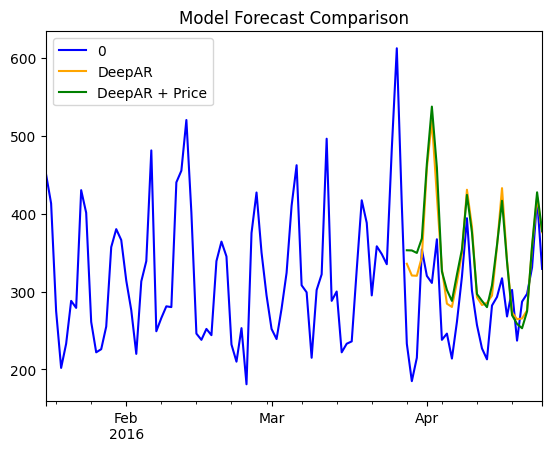

In [26]:
import matplotlib.pyplot as plt

# Choose first time series
ts = tss_base[0]

forecast_base = forecasts_base[0]
forecast_econ = forecasts_econ[0]

plt.figure(figsize=(12,6))

# Actual values
ts[-100:].plot(color='blue', label="Actual")

# Base model prediction (median)
plt.plot(forecast_base.index, forecast_base.quantile(0.5), color='orange', label="DeepAR")

# Econ model prediction (median)
plt.plot(forecast_econ.index, forecast_econ.quantile(0.5), color='green', label="DeepAR + Price")

plt.title("Model Forecast Comparison")
plt.legend()
plt.show()